<a href="https://colab.research.google.com/github/AnshulDiwakar/AnshulDiwakar-Simple-Life-Hospital-Management-System/blob/main/Machine_Learning_Algorithm_for_Real_Time_Breast_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries



In [1]:
# Core libraries
import os
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


## 1. Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive (3).zip to archive (3).zip


In [ ]:
import zipfile

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [ ]:
base_dir = '/content/dataset'

for root, dirs, files in os.walk(base_dir):
    print(root)
    break


/content/dataset


In [ ]:
import os

base_dir = '/content/dataset'

for root, dirs, files in os.walk(base_dir):
    print("ROOT:", root)
    print("DIRS:", dirs)
    break


ROOT: /content/dataset
DIRS: ['Dataset_BUSI_with_GT']


In [ ]:
import os

base_dir = '/content/dataset/Dataset_BUSI_with_GT'

print("Folders inside dataset:")
print(os.listdir(base_dir))


Folders inside dataset:
['malignant', 'benign', 'normal']


In [ ]:
benign_dir = os.path.join(base_dir, 'benign')
malignant_dir = os.path.join(base_dir, 'malignant')


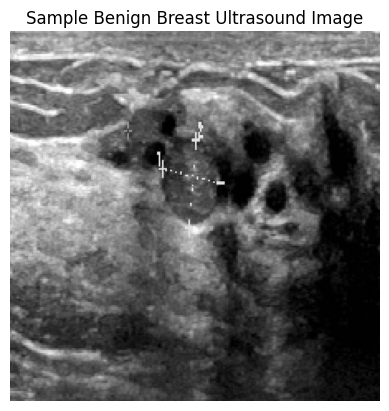

In [ ]:
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

# Benign image
benign_img = random.choice(os.listdir(benign_dir))
img = load_img(os.path.join(benign_dir, benign_img), target_size=(224,224))

plt.imshow(img)
plt.title("Sample Benign Breast Ultrasound Image")
plt.axis('off')
plt.show()


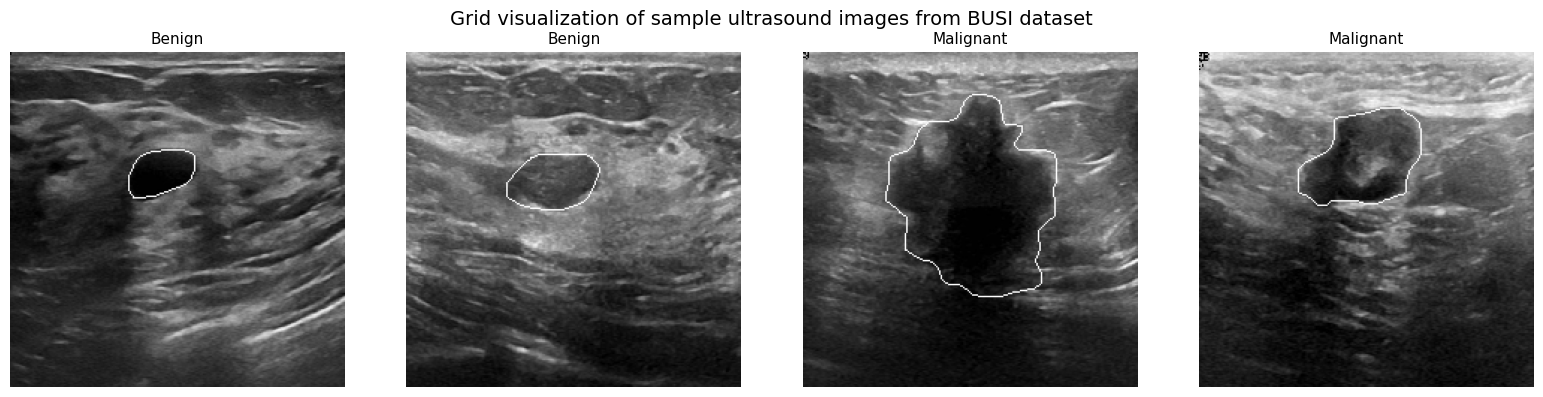

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

benign_dir = '/content/dataset/Dataset_BUSI_with_GT/benign'
malignant_dir = '/content/dataset/Dataset_BUSI_with_GT/malignant'

def get_real_images(folder):
    return [f for f in os.listdir(folder) if not f.endswith('_mask.png')]

def draw_white_boundary(image_path, mask_path):
    img = load_img(image_path, target_size=(224, 224))
    img_arr = img_to_array(img).astype(np.uint8)

    mask = load_img(mask_path, target_size=(224, 224), color_mode='grayscale')
    mask_arr = img_to_array(mask).astype(np.uint8)[:, :, 0]

    contours, _ = cv2.findContours(
        mask_arr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    output = img_arr.copy()
    cv2.drawContours(output, contours, -1, (255, 255, 255), 1)  # slim white line
    return output

# Pick images
benign_imgs = random.sample(get_real_images(benign_dir), 2)
malignant_imgs = random.sample(get_real_images(malignant_dir), 2)

all_images = [(benign_dir, img, "Benign") for img in benign_imgs] + \
             [(malignant_dir, img, "Malignant") for img in malignant_imgs]

plt.figure(figsize=(16, 4))

for i, (folder, img_name, label) in enumerate(all_images):
    img_path = os.path.join(folder, img_name)
    mask_path = os.path.join(folder, img_name.replace('.png', '_mask.png'))

    result = draw_white_boundary(img_path, mask_path)

    plt.subplot(1, 4, i + 1)
    plt.imshow(result, cmap='gray')
    plt.title(label, fontsize=11)
    plt.axis('off')

plt.suptitle("Grid visualization of sample ultrasound images from BUSI dataset", fontsize=14)
plt.tight_layout()
plt.show()




In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
import random
import os

# Number of images to display
num_images = 6

benign_samples = random.sample(benign_images, num_images//2)
malignant_samples = random.sample(malignant_images, num_images//2)

plt.figure(figsize=(10,5))

# Plot benign images
for i, img_name in enumerate(benign_samples):
    img = load_img(os.path.join(benign_dir, img_name), target_size=(224,224))
    plt.subplot(2, num_images//2, i+1)
    plt.imshow(img, cmap='gray')
    plt.title("Benign")
    plt.axis('off')

# Plot malignant images
for i, img_name in enumerate(malignant_samples):
    img = load_img(os.path.join(malignant_dir, img_name), target_size=(224,224))
    plt.subplot(2, num_images//2, i+1+num_images//2)
    plt.imshow(img, cmap='gray')
    plt.title("Malignant")
    plt.axis('off')

plt.suptitle("Sample Breast Ultrasound Images from BUSI Dataset")
plt.show()


NameError: name 'benign_images' is not defined

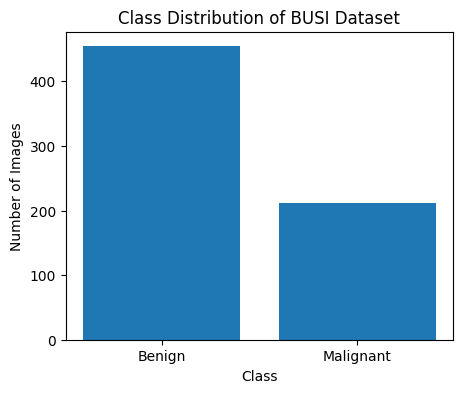

In [ ]:
import matplotlib.pyplot as plt

labels = ['Benign', 'Malignant']
counts = [len(benign_images), len(malignant_images)]

plt.figure(figsize=(5,4))
plt.bar(labels, counts)
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution of BUSI Dataset')
plt.show()


In [ ]:
def get_real_images(folder):
    return [f for f in os.listdir(folder) if not f.endswith('_mask.png')]


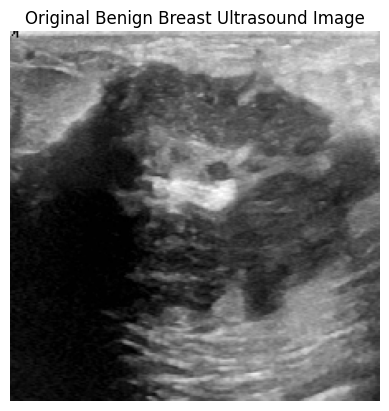

In [ ]:
real_benign_images = get_real_images(benign_dir)

img_path = random.choice(real_benign_images)
img = load_img(os.path.join(benign_dir, img_path), target_size=(224,224))

plt.imshow(img, cmap='gray')
plt.title("Original Benign Breast Ultrasound Image")
plt.axis('off')
plt.show()


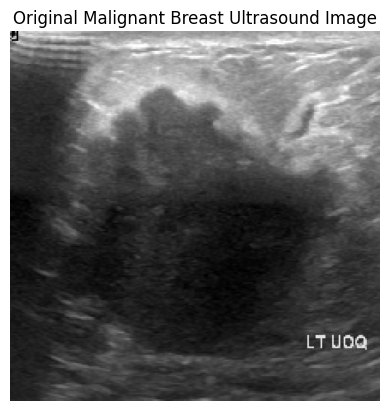

In [ ]:
real_malignant_images = get_real_images(malignant_dir)

img_path = random.choice(real_malignant_images)
img = load_img(os.path.join(malignant_dir, img_path), target_size=(224,224))

plt.imshow(img, cmap='gray')
plt.title("Original Malignant Breast Ultrasound Image")
plt.axis('off')
plt.show()


## CNN STEP 2: IMAGE PREPROCESSING & DATA GENERATOR

* 2.1: DEFINE IMAGE PARAMETERS

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16


* 2.2: CREATE CLEAN IMAGE LISTS (NO MASKS)

In [ ]:
def get_real_images(folder):
    return [f for f in os.listdir(folder) if not f.endswith('_mask.png')]

benign_images = get_real_images(benign_dir)
malignant_images = get_real_images(malignant_dir)

print("Benign images:", len(benign_images))
print("Malignant images:", len(malignant_images))


Benign images: 454
Malignant images: 211


* 2.3: CREATE A TEMP TRAINING DIRECTORY (IMPORTANT)

In [ ]:
import shutil

base_data_dir = '/content/cnn_data'
train_dir = os.path.join(base_data_dir, 'train')
val_dir = os.path.join(base_data_dir, 'validation')

for category in ['benign', 'malignant']:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(val_dir, category), exist_ok=True)


* 2.4: SPLIT DATA (80% TRAIN / 20% VALIDATION)

In [ ]:
from sklearn.model_selection import train_test_split

benign_train, benign_val = train_test_split(
    benign_images, test_size=0.2, random_state=42)

malignant_train, malignant_val = train_test_split(
    malignant_images, test_size=0.2, random_state=42)


* 2.5: COPY IMAGES INTO TRAIN & VALIDATION FOLDERS

In [ ]:
def copy_images(image_list, src_dir, dest_dir):
    for img in image_list:
        shutil.copy(os.path.join(src_dir, img), dest_dir)

# Copy benign images
copy_images(benign_train, benign_dir, os.path.join(train_dir, 'benign'))
copy_images(benign_val, benign_dir, os.path.join(val_dir, 'benign'))

# Copy malignant images
copy_images(malignant_train, malignant_dir, os.path.join(train_dir, 'malignant'))
copy_images(malignant_val, malignant_dir, os.path.join(val_dir, 'malignant'))

print("Images copied successfully!")


Images copied successfully!


* 2.6: IMAGE NORMALIZATION & AUGMENTATION

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)


* 2.7: CREATE DATA GENERATORS (CNN-READY)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale'
)


Found 531 images belonging to 2 classes.
Found 134 images belonging to 2 classes.


## CNN STEP 3: BUILD CNN ARCHITECTURE

* 3.1: IMPORT CNN LAYERS

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


* 3.2: BUILD THE CNN MODEL

In [ ]:
model = Sequential([

    # Convolution Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* 3.3: COMPILE THE MODEL

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

## CNN STEP 4: TRAIN THE CNN MODEL

In [ ]:
EPOCHS = 20
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.6793 - loss: 0.6680 - val_accuracy: 0.7612 - val_loss: 0.5520
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.7244 - loss: 0.5787 - val_accuracy: 0.7388 - val_loss: 0.4890
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.7586 - loss: 0.5554 - val_accuracy: 0.7537 - val_loss: 0.4916
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7470 - loss: 0.5294 - val_accuracy: 0.7761 - val_loss: 0.4398
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7825 - loss: 0.4877 - val_accuracy: 0.7910 - val_loss: 0.4043
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8137 - loss: 0.4695 - val_accuracy: 0.8060 - val_loss: 0.4184
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8068 - loss: 0.4461 - val_accuracy: 0.7985 - val_loss: 0.3938
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.7793 - loss: 0.5077 - val_accuracy: 0.7985 - val_loss:

* 4.3: PLOT TRAINING & VALIDATION ACCURACY

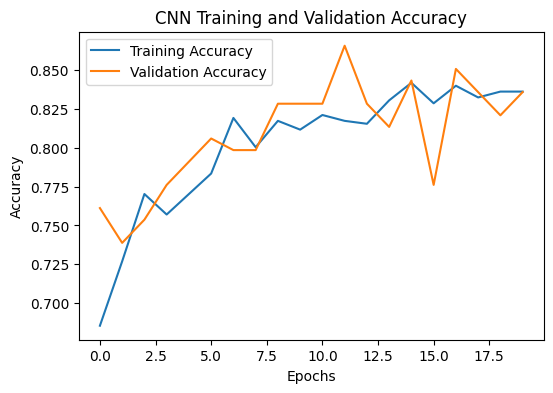

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()
plt.show()


* 4.4: PLOT TRAINING & VALIDATION LOSS

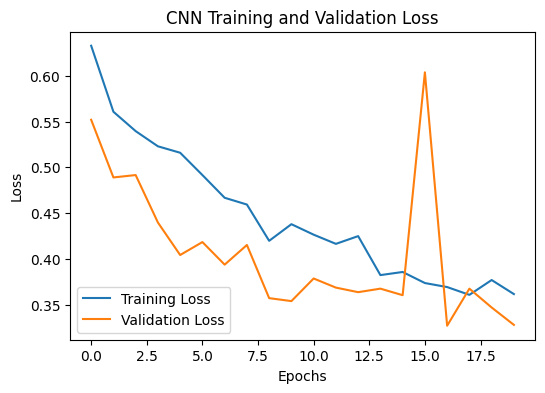

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()
plt.show()


## CNN STEP 5: MODEL EVALUATION

* 5.1: EVALUATE MODEL ON VALIDATION DATA

In [ ]:
val_loss, val_accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")


9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 396ms/step - accuracy: 0.8482 - loss: 0.3212
Validation Accuracy: 83.58%


* 5.2: GET PREDICTIONS FROM CNN

In [ ]:
import numpy as np

# Get true labels
y_true = val_generator.classes

# Predict probabilities
y_pred_prob = model.predict(val_generator)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 548ms/step


* 5.3: CONFUSION MATRIX

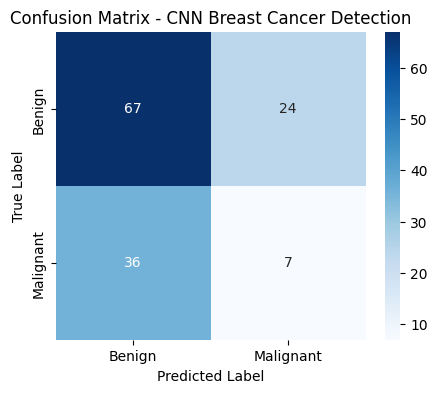

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CNN Breast Cancer Detection')
plt.show()


* 5.4: CLASSIFICATION REPORT

In [ ]:
print(classification_report(
    y_true, y_pred,
    target_names=['Benign', 'Malignant']
))


              precision    recall  f1-score   support

      Benign       0.65      0.74      0.69        91
   Malignant       0.23      0.16      0.19        43

    accuracy                           0.55       134
   macro avg       0.44      0.45      0.44       134
weighted avg       0.51      0.55      0.53       134



## FUNCTION TO DISPLAY OVERLAY

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def show_professional_tumor_borders(benign_dir, malignant_dir, num_each=3):
    plt.figure(figsize=(14, 6))

    all_cases = [
        (benign_dir, "Benign Tumor"),
        (malignant_dir, "Malignant Tumor")
    ]

    plot_index = 1

    for folder, label_text in all_cases:
        images = [f for f in os.listdir(folder) if not f.endswith('_mask.png')]
        selected_images = random.sample(images, num_each)

        for img_name in selected_images:
            mask_name = img_name.replace('.png', '_mask.png')

            img_path = os.path.join(folder, img_name)
            mask_path = os.path.join(folder, mask_name)

            # Load image
            img = load_img(img_path, target_size=(224,224))
            img_array = img_to_array(img).astype(np.uint8)

            # Load mask
            mask = load_img(mask_path, target_size=(224,224), color_mode='grayscale')
            mask_array = img_to_array(mask).astype(np.uint8)[:,:,0]

            # Find contours
            contours, _ = cv2.findContours(
                mask_array, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            # Draw red contour on image
            bordered_img = img_array.copy()
            cv2.drawContours(bordered_img, contours, -1, (255, 0, 0), 2)

            # Plot
            plt.subplot(2, num_each, plot_index)
            plt.imshow(bordered_img)
            plt.title(label_text, fontsize=10, color='black')
            plt.axis('off')

            plot_index += 1

    plt.suptitle(
        "Tumor Boundary Visualization in Breast Ultrasound Images",
        fontsize=14
    )
    plt.show()


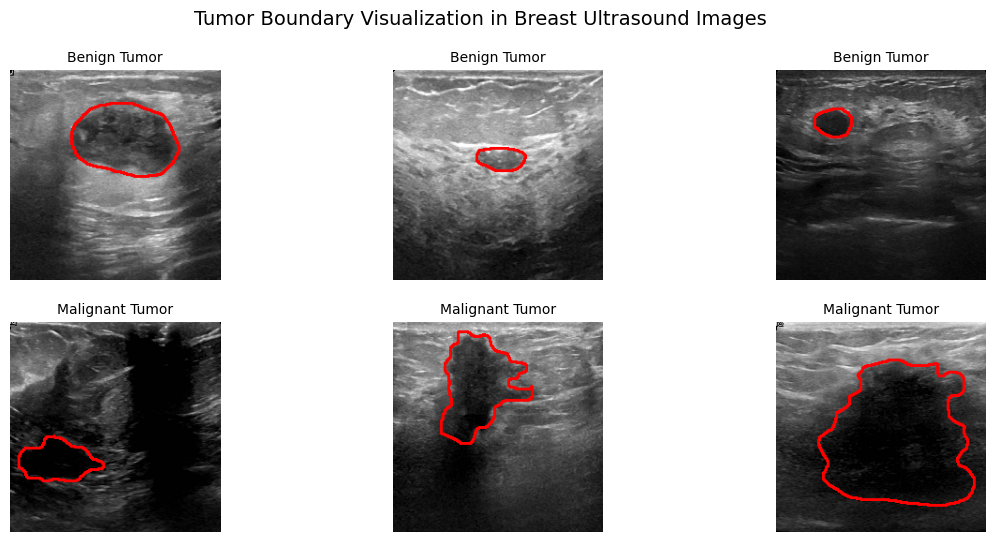

In [ ]:
show_professional_tumor_borders(benign_dir, malignant_dir, num_each=3)


In [ ]:
# Evaluate model on validation data
val_loss, val_accuracy = model.evaluate(val_generator)

print("===================================")
print(f"Final Testing (Validation) Accuracy: {val_accuracy * 100:.2f}%")
print("===================================")


# Count images (excluding masks)
num_benign = len(benign_images)
num_malignant = len(malignant_images)

total_images = num_benign + num_malignant

print("===================================")
print(f"Number of Benign Images     : {num_benign}")
print(f"Number of Malignant Images  : {num_malignant}")
print(f"Total Images Used           : {total_images}")
print("===================================")

# Training and validation counts
train_benign = len(os.listdir(os.path.join(train_dir, 'benign')))
train_malignant = len(os.listdir(os.path.join(train_dir, 'malignant')))

val_benign = len(os.listdir(os.path.join(val_dir, 'benign')))
val_malignant = len(os.listdir(os.path.join(val_dir, 'malignant')))

print("========== DATA SPLIT ==========")
print(f"Training - Benign     : {train_benign}")
print(f"Training - Malignant  : {train_malignant}")
print(f"Validation - Benign   : {val_benign}")
print(f"Validation - Malignant: {val_malignant}")
print("================================")



9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 517ms/step - accuracy: 0.8476 - loss: 0.3140
Final Testing (Validation) Accuracy: 83.58%
Number of Benign Images     : 454
Number of Malignant Images  : 211
Total Images Used           : 665
========== DATA SPLIT ==========
Training - Benign     : 363
Training - Malignant  : 168
Validation - Benign   : 91
Validation - Malignant: 43


## CNN MODULE FLOW CHART

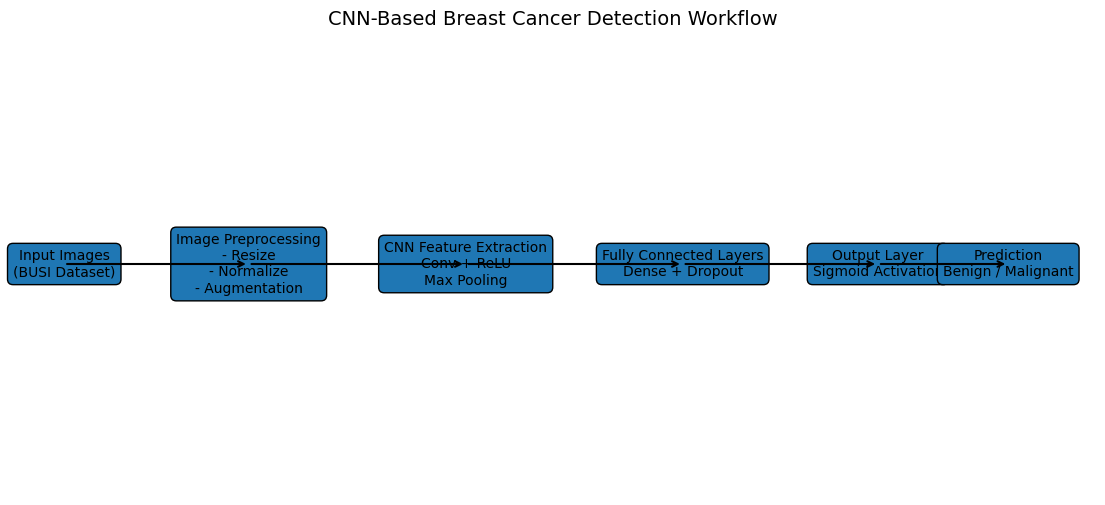

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Box positions
boxes = {
    "Input Images\n(BUSI Dataset)": (0.05, 0.5),
    "Image Preprocessing\n- Resize\n- Normalize\n- Augmentation": (0.22, 0.5),
    "CNN Feature Extraction\nConv + ReLU\nMax Pooling": (0.42, 0.5),
    "Fully Connected Layers\nDense + Dropout": (0.62, 0.5),
    "Output Layer\nSigmoid Activation": (0.80, 0.5),
    "Prediction\nBenign / Malignant": (0.92, 0.5)
}

# Draw boxes
for text, (x, y) in boxes.items():
    plt.text(
        x, y, text,
        ha='center', va='center',
        bbox=dict(boxstyle="round,pad=0.4", edgecolor='black'),
        fontsize=10
    )

# Draw arrows
arrow_props = dict(arrowstyle="->", lw=1.5)
positions = list(boxes.values())

for i in range(len(positions)-1):
    plt.annotate(
        "",
        xy=positions[i+1],
        xytext=positions[i],
        arrowprops=arrow_props
    )

plt.title("CNN-Based Breast Cancer Detection Workflow", fontsize=14)
plt.axis('off')
plt.show()


In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def show_tumor_with_size(image_dir, title, label_text, num_images=3):
    images = [f for f in os.listdir(image_dir) if not f.endswith('_mask.png')]
    selected = random.sample(images, num_images)

    plt.figure(figsize=(12, 4))

    for i, img_name in enumerate(selected):
        mask_name = img_name.replace(".png", "_mask.png")

        img_path = os.path.join(image_dir, img_name)
        mask_path = os.path.join(image_dir, mask_name)

        # Load image
        img = load_img(img_path, target_size=(224,224))
        img_arr = img_to_array(img).astype(np.uint8)

        # Load mask
        mask = load_img(mask_path, target_size=(224,224), color_mode="grayscale")
        mask_arr = img_to_array(mask).astype(np.uint8)[:,:,0]

        # Tumor size (area in pixels)
        tumor_area = np.sum(mask_arr > 0)

        # Find contours
        contours, _ = cv2.findContours(
            mask_arr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        # Draw yellow contour
        bordered = img_arr.copy()
        cv2.drawContours(bordered, contours, -1, (255, 255, 0), 2)

        # Add text
        cv2.putText(
            bordered,
            f"Size: {tumor_area} px",
            (5, 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 0),
            1
        )

        # Plot
        plt.subplot(1, num_images, i+1)
        plt.imshow(bordered)
        plt.title(label_text, fontsize=10)
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.show()


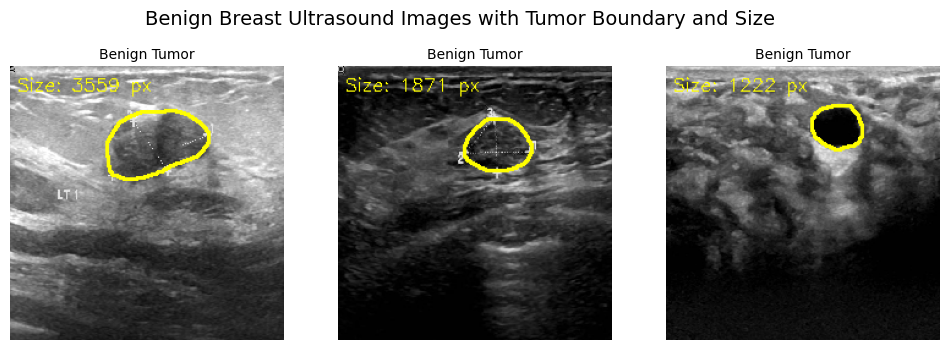

In [ ]:
show_tumor_with_size(
    benign_dir,
    title="Benign Breast Ultrasound Images with Tumor Boundary and Size",
    label_text="Benign Tumor",
    num_images=3
)


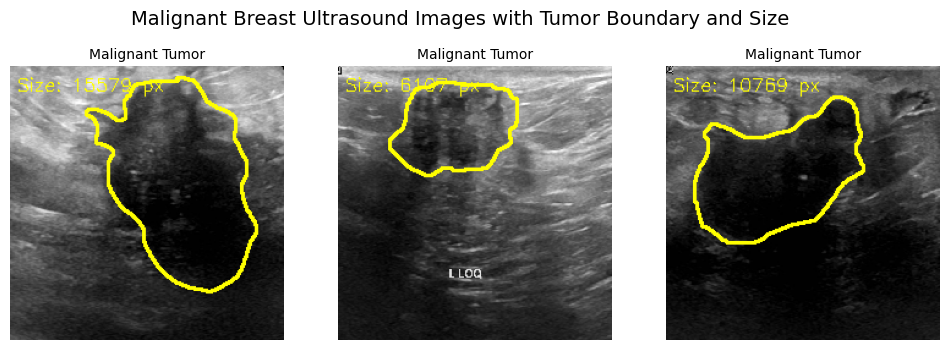

In [ ]:
show_tumor_with_size(
    malignant_dir,
    title="Malignant Breast Ultrasound Images with Tumor Boundary and Size",
    label_text="Malignant Tumor",
    num_images=3
)
